In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
from dataset import load_dataset
from sklearn.feature_selection import f_regression
plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

In [9]:
TRAIN_PATH_FULL = "../../data/processed/full_train/train.csv"
TRAIN_PATH_SPLIT = "../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT  = "../../data/processed/split_85_15/test_15.csv"
TARGET_COL = "faulty"
FEUTURE=["trq_margin","oat","pa","np_ng_ratio","ias","mgt"]

In [10]:
train_df=load_dataset(TRAIN_PATH_SPLIT).drop(["trq_target"], axis=1)
X_train = train_df[FEUTURE].values
y_train = train_df[TARGET_COL].values

<Axes: >

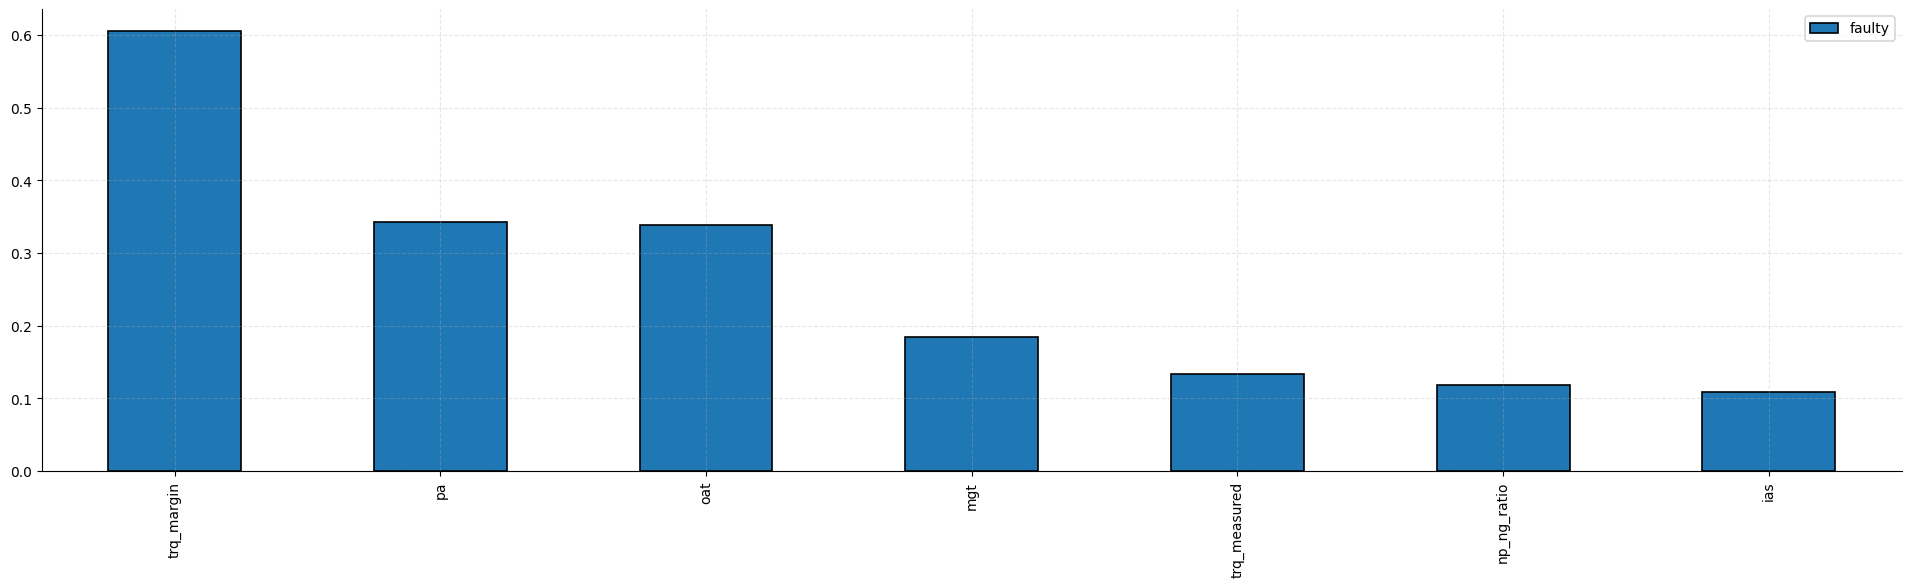

In [11]:
corr_with_faulty = (
    train_df.corr()[['faulty']]
    .drop(index=['faulty'])
).abs().sort_values(by='faulty', ascending=False)
corr_with_faulty.plot(kind='bar', figsize=(24, 6))

<Axes: >

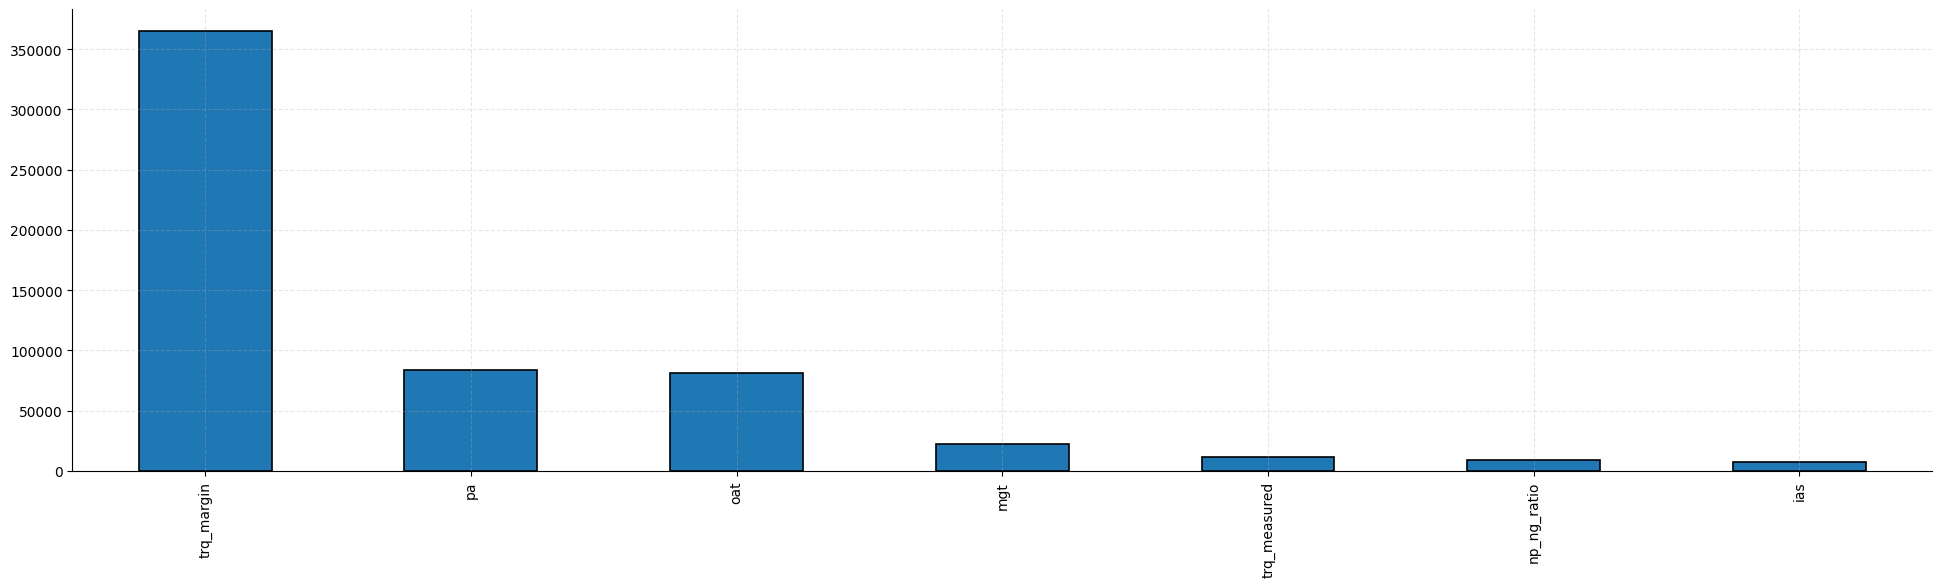

In [12]:
f=train_df.copy()
F, p_values = f_regression(f.drop(['faulty'], axis=1), f['faulty'])
f_scores = pd.Series(F, index=f.drop(['faulty'], axis=1).columns).sort_values(
    ascending=False)
f_scores.plot(kind='bar', figsize=(24, 6))

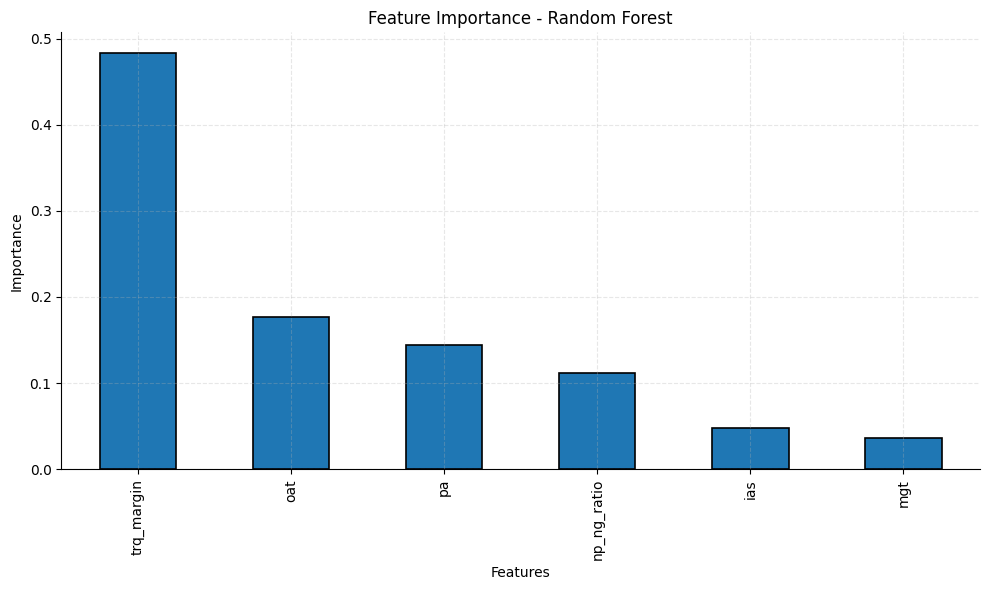

In [13]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=FEUTURE)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

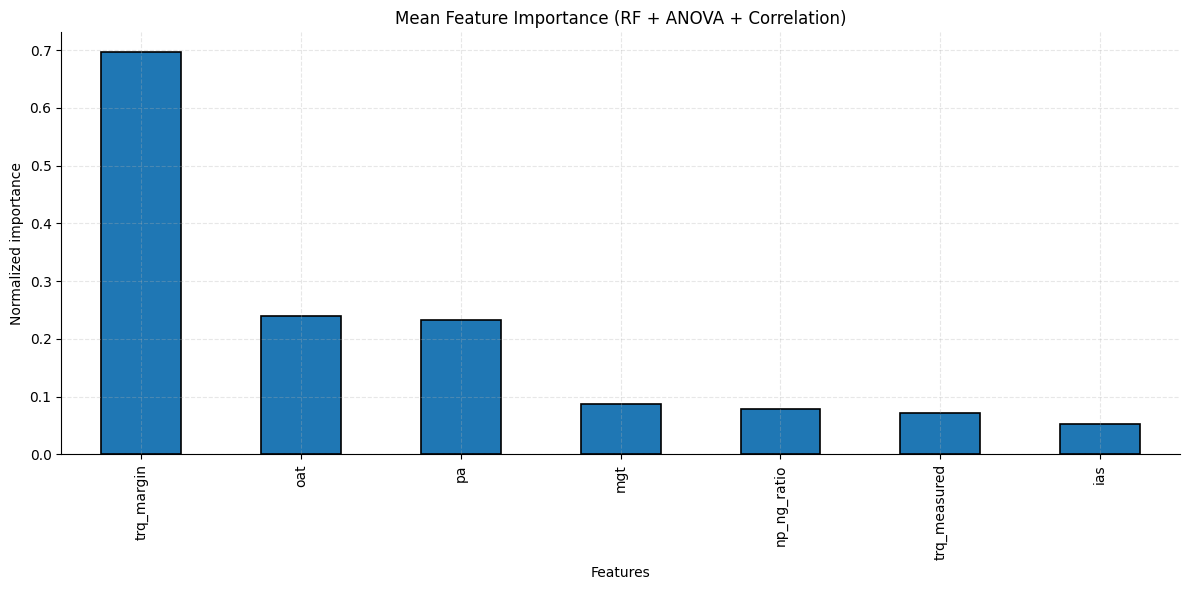

In [14]:
feat_imp.name = "RF"
f_scores.name = "ANOVA"
corr_with_faulty.name = "Correlation"

feat_compare = pd.concat(
    [feat_imp, f_scores, corr_with_faulty],
    axis=1
)

scaler = MinMaxScaler()

scaler = MinMaxScaler()

feat_compare["ANOVA"] = scaler.fit_transform(
    feat_compare[["ANOVA"]]
)
feat_compare["Mean_importance"] = feat_compare.mean(axis=1)

feat_norm = feat_compare.sort_values(
    "Mean_importance",
    ascending=False
)

plt.figure(figsize=(12, 6))

feat_norm["Mean_importance"].plot(kind="bar")

plt.title("Mean Feature Importance (RF + ANOVA + Correlation)")
plt.ylabel("Normalized importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()
